# Diabetes Prediction - Data Mining Project

Pima Indians Diabetes Dataset (768 patients, 8 features + target).

Tasks:
1. Descriptive statistics and data exploration
2. Data cleaning (missing values disguised as zeros)
3. Outlier detection using Z-Score
4. Classification: KNN, Decision Tree, Naive Bayes, Random Forest, XGBoost
5. Clustering: K-Means, K-Medoids, DBSCAN, STING, CLIQUE
6. Association rule mining using Apriori


## 1. Setup

In [1]:
# !pip install mlxtend scikit-learn-extra xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score, silhouette_score)

from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.cluster import KMeans, DBSCAN
from sklearn_extra.cluster import KMedoids

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from scipy.stats import zscore

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Visual style for all plots
NAVY, TEAL, CORAL, GOLD = '#1a365d', '#2c7a7b', '#e53e3e', '#d69e2e'
GRAY, MINT, SOFT = '#4a5568', '#38b2ac', '#e2e8f0'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#cbd5e0',
    'axes.labelcolor': NAVY,
    'axes.titlecolor': NAVY,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.color': GRAY,
    'ytick.color': GRAY,
    'grid.color': '#edf2f7',
    'grid.linewidth': 0.8,
    'font.family': 'DejaVu Sans',
})

## 2. Load the Dataset

In [2]:
df = pd.read_csv('diabetes.csv')

print("Dataset shape:", df.shape)
print("Class distribution:")
print(df['Outcome'].value_counts())
print(f"Positive class: {df['Outcome'].mean()*100:.1f}%")
df.head()

Dataset shape: (768, 9)
Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
Positive class: 34.9%


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Descriptive Statistics

Summary statistics for the Glucose column.

In [3]:
feature = df['Glucose']
stats_summary = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Mode', 'Variance', 'Std Deviation', 'Min', 'Max'],
    'Value': [np.mean(feature), np.median(feature), feature.mode().iloc[0],
              np.var(feature), np.std(feature), np.min(feature), np.max(feature)]
})
print(stats_summary.to_string(index=False))

    Statistic       Value
         Mean  120.894531
       Median  117.000000
         Mode   99.000000
     Variance 1020.917262
Std Deviation   31.951796
          Min    0.000000
          Max  199.000000


## 4. Data Exploration

In [4]:
df.info()
print()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 5. Data Cleaning

In this dataset, a value of 0 in some columns is not physiologically possible and should be treated as missing:

- Glucose, BloodPressure, SkinThickness, Insulin, BMI

Replacing zeros with NaN, then imputing with the median (more robust to outliers than the mean).

In [5]:
cols_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zeros in each column before cleaning:")
for col in cols_with_invalid_zeros:
    count = (df[col] == 0).sum()
    pct = count / len(df) * 100
    print(f"  {col:20s}: {count:3d} ({pct:.1f}%)")

df_clean = df.copy()
df_clean[cols_with_invalid_zeros] = df_clean[cols_with_invalid_zeros].replace(0, np.nan)

print("\nMissing values after replacing zeros with NaN:")
print(df_clean[cols_with_invalid_zeros].isna().sum())

for col in cols_with_invalid_zeros:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("\nAfter imputation:")
print(df_clean[cols_with_invalid_zeros].describe().loc[['min', 'mean', 'max']])

Zeros in each column before cleaning:
  Glucose             :   5 (0.7%)
  BloodPressure       :  35 (4.6%)
  SkinThickness       : 227 (29.6%)
  Insulin             : 374 (48.7%)
  BMI                 :  11 (1.4%)

Missing values after replacing zeros with NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

After imputation:
        Glucose  BloodPressure  SkinThickness     Insulin        BMI
min    44.00000      24.000000       7.000000   14.000000  18.200000
mean  121.65625      72.386719      29.108073  140.671875  32.455208
max   199.00000     122.000000      99.000000  846.000000  67.100000


## 6. Outlier Detection (Z-Score)

A point is flagged as an outlier when |z| > 3.

Outliers in Glucose (|z| > 3): 0


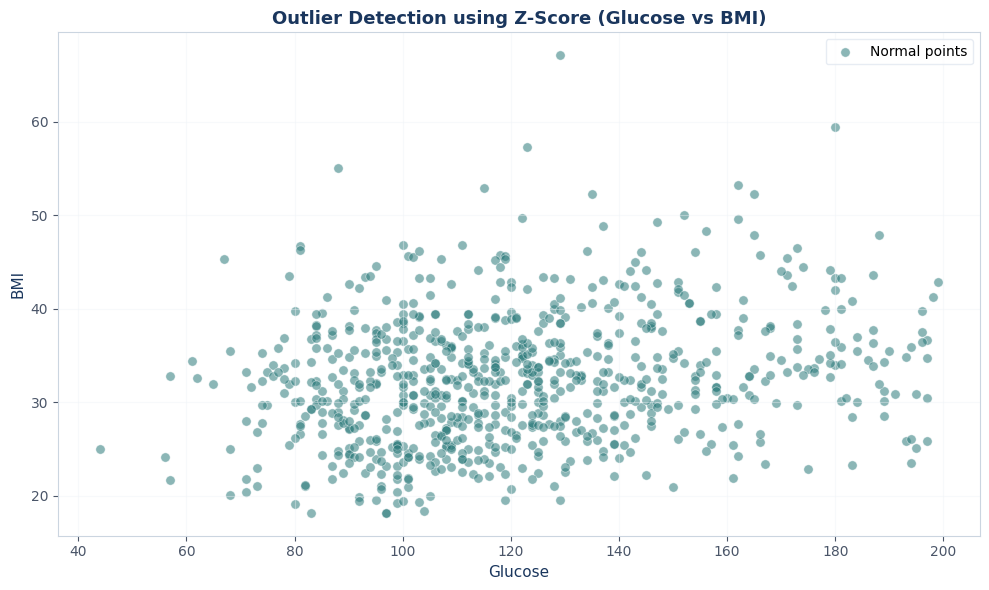

In [6]:
df_clean.loc[:, 'Glucose_zscore'] = zscore(df_clean['Glucose'])
outliers = df_clean[np.abs(df_clean['Glucose_zscore']) > 3]
print(f"Outliers in Glucose (|z| > 3): {len(outliers)}")
if len(outliers) > 0:
    print(outliers[['Glucose', 'BMI', 'Age', 'Outcome', 'Glucose_zscore']])

plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Glucose'], df_clean['BMI'],
            label='Normal points', alpha=0.55, c=TEAL, s=45, edgecolors='white', linewidth=0.5)
if len(outliers) > 0:
    plt.scatter(outliers['Glucose'], outliers['BMI'],
                color=CORAL, s=120, label='Outliers',
                edgecolors=NAVY, linewidth=1.5, zorder=5)
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Outlier Detection using Z-Score (Glucose vs BMI)')
plt.legend(frameon=True, facecolor='white', edgecolor=SOFT)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()
df_clean = df_clean.drop(columns=['Glucose_zscore'])

## 7. Exploratory Visualization

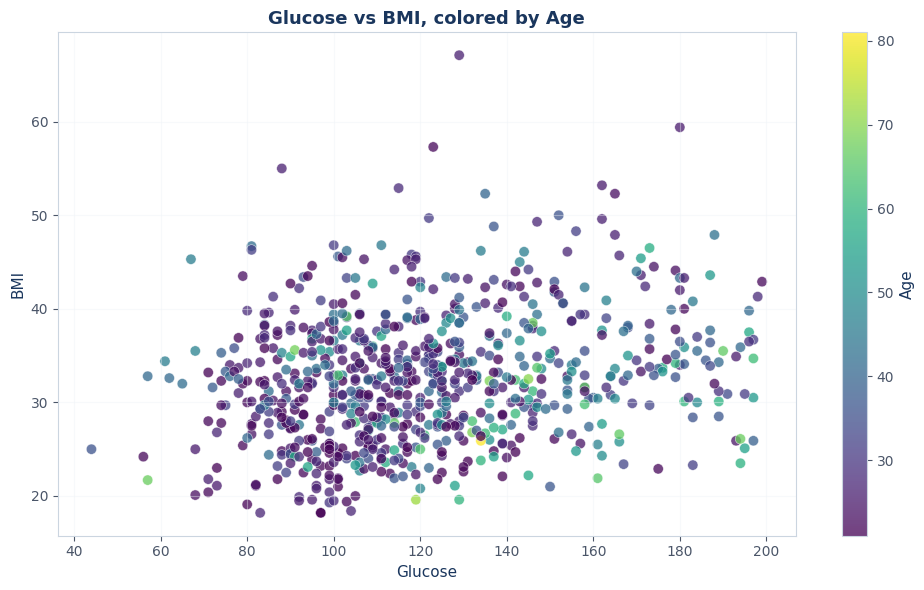

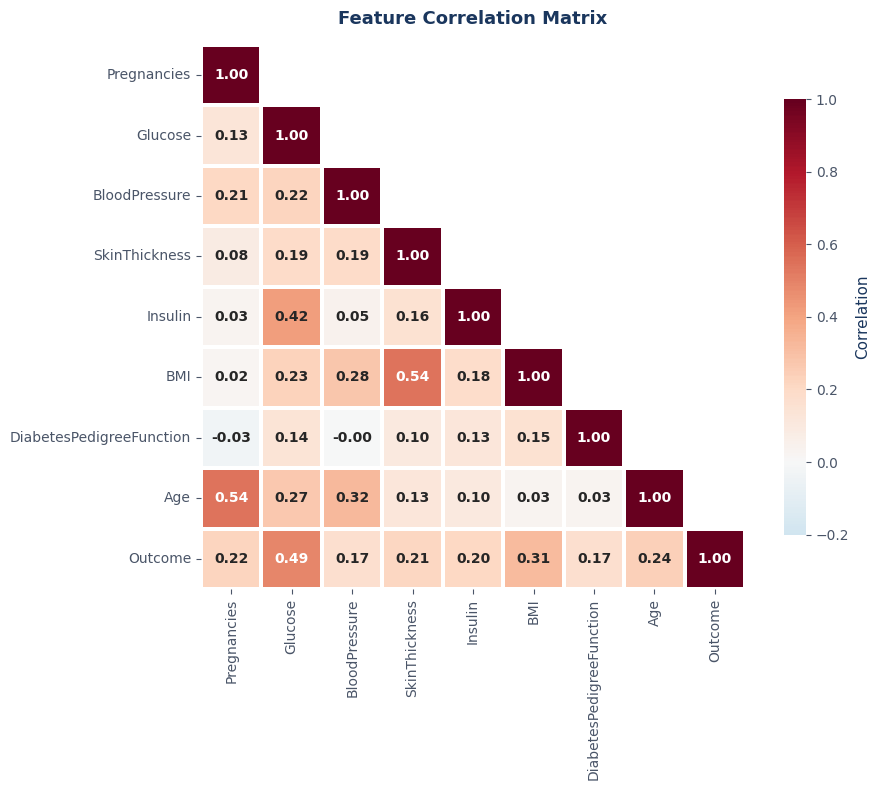

In [7]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(df_clean['Glucose'], df_clean['BMI'],
                 c=df_clean['Age'], cmap='viridis', alpha=0.75, s=55,
                 edgecolors='white', linewidth=0.4)
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Glucose vs BMI, colored by Age')
cbar = plt.colorbar(sc)
cbar.set_label('Age', color=NAVY)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# Correlation heatmap with a cleaner palette
plt.figure(figsize=(10, 8))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-0.2, vmax=1.0,
            square=True, mask=mask,
            linewidths=1.5, linecolor='white',
            cbar_kws={'label': 'Correlation', 'shrink': 0.8},
            annot_kws={'size': 10, 'weight': 'bold'})
plt.title('Feature Correlation Matrix', pad=15)
plt.tight_layout()
plt.show()

## 8. Train/Test Split and Scaling

80/20 split with stratification. StandardScaler for KNN and clustering.

In [8]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)
print("Train class distribution:", y_train.value_counts().to_dict())
print("Test class distribution: ", y_test.value_counts().to_dict())

Training set: (614, 8)
Test set:     (154, 8)
Train class distribution: {0: 400, 1: 214}
Test class distribution:  {0: 100, 1: 54}


# Part 1: Classification

Metrics: Accuracy, Precision/Recall, F1, 5-Fold CV, Confusion Matrix.

## 9. K-Nearest Neighbors (KNN)

KNN Test Accuracy: 0.7532
KNN Test F1:       0.6346
KNN 5-Fold CV F1:  0.6099

              precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81       100
    Diabetes       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



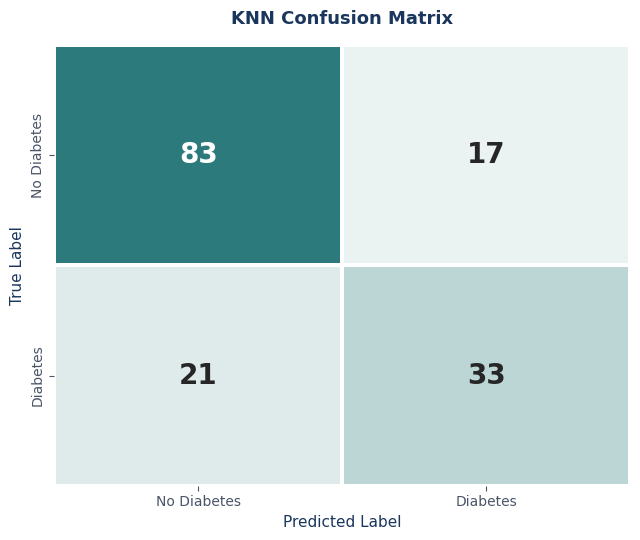

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn)
cv_knn  = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='f1').mean()

print(f"KNN Test Accuracy: {acc_knn:.4f}")
print(f"KNN Test F1:       {f1_knn:.4f}")
print(f"KNN 5-Fold CV F1:  {cv_knn:.4f}")
print()
print(classification_report(y_test, y_pred_knn,
                            target_names=['No Diabetes', 'Diabetes']))

cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt='d',
            cmap=sns.light_palette(TEAL, as_cmap=True),
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            linewidths=1.5, linecolor='white',
            cbar=False,
            annot_kws={'size': 20, 'weight': 'bold'})
plt.title('KNN Confusion Matrix', pad=15)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 10. Decision Tree

Using max_depth=5 to avoid overfitting.

Decision Tree Test Accuracy: 0.7597
Decision Tree Test F1:       0.6783
Decision Tree 5-Fold CV F1:  0.5643

              precision    recall  f1-score   support

 No Diabetes       0.84      0.78      0.81       100
    Diabetes       0.64      0.72      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154


Feature Importances:
                 Feature  Importance
                 Glucose    0.572875
                     BMI    0.200880
                     Age    0.111960
                 Insulin    0.037006
DiabetesPedigreeFunction    0.033923
           BloodPressure    0.030970
           SkinThickness    0.012386
             Pregnancies    0.000000


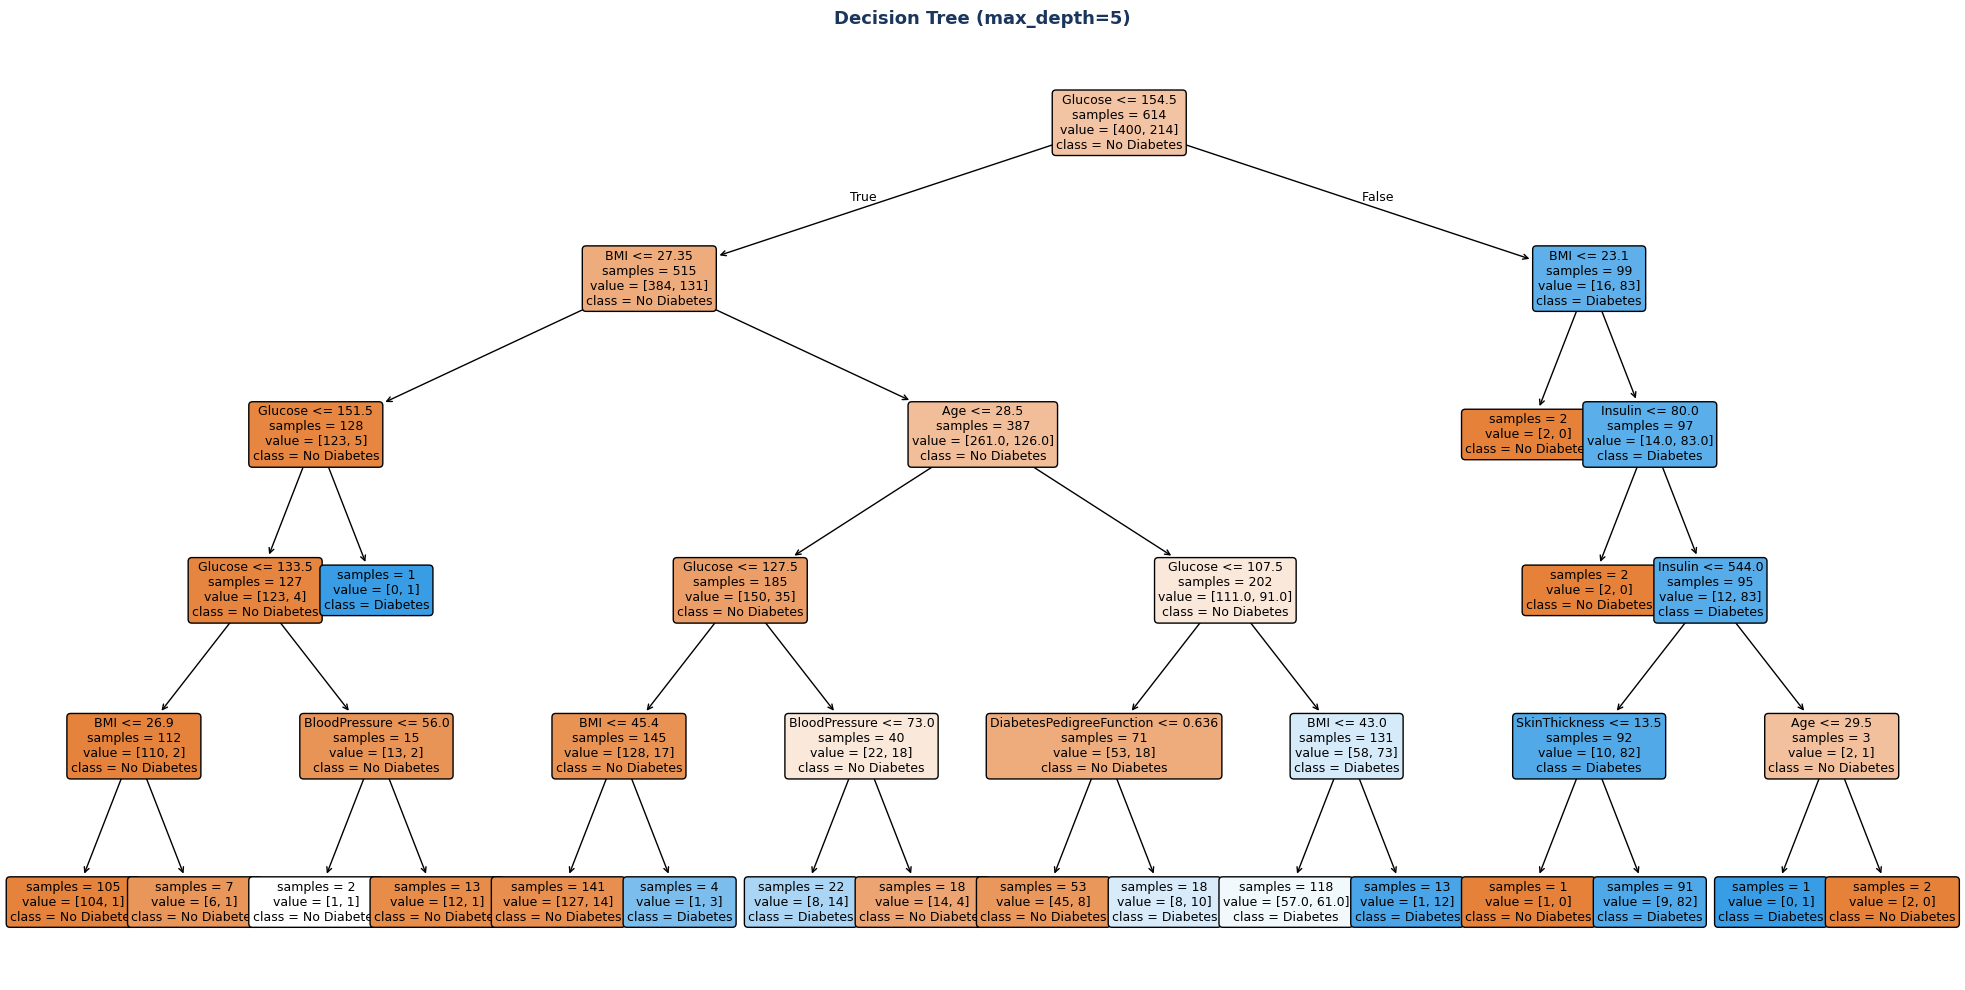

In [10]:
dtc = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dtc.fit(X_train, y_train)
y_pred_dt = dtc.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt)
cv_dt  = cross_val_score(dtc, X_train, y_train, cv=5, scoring='f1').mean()

print(f"Decision Tree Test Accuracy: {acc_dt:.4f}")
print(f"Decision Tree Test F1:       {f1_dt:.4f}")
print(f"Decision Tree 5-Fold CV F1:  {cv_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt,
                            target_names=['No Diabetes', 'Diabetes']))

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dtc.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importances:")
print(importances.to_string(index=False))

plt.figure(figsize=(20, 10))
plot_tree(dtc, feature_names=X.columns,
          class_names=['No Diabetes', 'Diabetes'],
          filled=True, rounded=True, fontsize=9,
          impurity=False)
plt.title('Decision Tree (max_depth=5)', pad=15)
plt.tight_layout()
plt.show()

## 11. Gaussian Naive Bayes

In [11]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb  = f1_score(y_test, y_pred_nb)
cv_nb  = cross_val_score(nb, X_train, y_train, cv=5, scoring='f1').mean()

print(f"Naive Bayes Test Accuracy: {acc_nb:.4f}")
print(f"Naive Bayes Test F1:       {f1_nb:.4f}")
print(f"Naive Bayes 5-Fold CV F1:  {cv_nb:.4f}")
print()
print(classification_report(y_test, y_pred_nb,
                            target_names=['No Diabetes', 'Diabetes']))

Naive Bayes Test Accuracy: 0.7013
Naive Bayes Test F1:       0.5965
Naive Bayes 5-Fold CV F1:  0.6272

              precision    recall  f1-score   support

 No Diabetes       0.79      0.74      0.76       100
    Diabetes       0.57      0.63      0.60        54

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.70      0.70       154



## 12. Random Forest

An ensemble of 100 decision trees, each trained on a random subset of the data and features. Final prediction is a majority vote. Usually more stable than a single tree.

In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf)
cv_rf  = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1').mean()

print(f"Random Forest Test Accuracy: {acc_rf:.4f}")
print(f"Random Forest Test F1:       {f1_rf:.4f}")
print(f"Random Forest 5-Fold CV F1:  {cv_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf,
                            target_names=['No Diabetes', 'Diabetes']))

rf_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nRandom Forest Feature Importances:")
print(rf_importances.to_string(index=False))

Random Forest Test Accuracy: 0.7792
Random Forest Test F1:       0.6531
Random Forest 5-Fold CV F1:  0.6433

              precision    recall  f1-score   support

 No Diabetes       0.80      0.88      0.84       100
    Diabetes       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154


Random Forest Feature Importances:
                 Feature  Importance
                 Glucose    0.274086
                     BMI    0.161903
DiabetesPedigreeFunction    0.125020
                     Age    0.112985
                 Insulin    0.091224
           BloodPressure    0.083518
             Pregnancies    0.080795
           SkinThickness    0.070468


## 13. XGBoost

Gradient boosting: trees are built sequentially, each one correcting the errors of the previous ones. Often strong on tabular data, though on small datasets it can be outperformed by Random Forest.

In [13]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1,
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb)
cv_xgb  = cross_val_score(xgb, X_train, y_train, cv=5, scoring='f1').mean()

print(f"XGBoost Test Accuracy: {acc_xgb:.4f}")
print(f"XGBoost Test F1:       {f1_xgb:.4f}")
print(f"XGBoost 5-Fold CV F1:  {cv_xgb:.4f}")
print()
print(classification_report(y_test, y_pred_xgb,
                            target_names=['No Diabetes', 'Diabetes']))

xgb_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nXGBoost Feature Importances:")
print(xgb_importances.to_string(index=False))

XGBoost Test Accuracy: 0.7468
XGBoost Test F1:       0.6286
XGBoost 5-Fold CV F1:  0.6024

              precision    recall  f1-score   support

 No Diabetes       0.80      0.82      0.81       100
    Diabetes       0.65      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.75      0.75       154


XGBoost Feature Importances:
                 Feature  Importance
                 Glucose    0.308556
                     BMI    0.166569
                     Age    0.116345
             Pregnancies    0.095891
                 Insulin    0.087873
DiabetesPedigreeFunction    0.083313
           BloodPressure    0.076510
           SkinThickness    0.064943


## 14. Hyperparameter Tuning with GridSearchCV

Tuning the two strongest "tunable" models (Random Forest and KNN). Each combination is evaluated with 5-fold cross-validation.

In [14]:
import time

print("Tuning Random Forest...")
rf_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}
t = time.time()
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_grid, cv=5, scoring='f1', n_jobs=-1
)
rf_search.fit(X_train, y_train)
rf_tune_time = time.time() - t

print(f"  Time: {rf_tune_time:.1f}s")
print(f"  Best CV F1: {rf_search.best_score_:.4f}")
print(f"  Best params: {rf_search.best_params_}")

rf_tuned = rf_search.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test)
acc_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
f1_rf_tuned  = f1_score(y_test, y_pred_rf_tuned)
cv_rf_tuned  = rf_search.best_score_

print(f"\n  Test Accuracy: {acc_rf_tuned:.4f}")
print(f"  Test F1:       {f1_rf_tuned:.4f}")
print(f"  Change vs default RF: CV F1 {cv_rf:.4f} -> {cv_rf_tuned:.4f} "
      f"({(cv_rf_tuned - cv_rf)*100:+.2f} pts)")

Tuning Random Forest...


  Time: 44.3s
  Best CV F1: 0.6460
  Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

  Test Accuracy: 0.7597
  Test F1:       0.6408
  Change vs default RF: CV F1 0.6433 -> 0.6460 (+0.27 pts)


In [15]:
print("Tuning KNN...")
knn_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}
t = time.time()
knn_search = GridSearchCV(
    KNeighborsClassifier(),
    knn_grid, cv=5, scoring='f1', n_jobs=-1
)
knn_search.fit(X_train_scaled, y_train)
knn_tune_time = time.time() - t

print(f"  Time: {knn_tune_time:.1f}s")
print(f"  Best CV F1: {knn_search.best_score_:.4f}")
print(f"  Best params: {knn_search.best_params_}")

knn_tuned = knn_search.best_estimator_
y_pred_knn_tuned = knn_tuned.predict(X_test_scaled)
acc_knn_tuned = accuracy_score(y_test, y_pred_knn_tuned)
f1_knn_tuned  = f1_score(y_test, y_pred_knn_tuned)
cv_knn_tuned  = knn_search.best_score_

print(f"\n  Test Accuracy: {acc_knn_tuned:.4f}")
print(f"  Test F1:       {f1_knn_tuned:.4f}")
print(f"  Change vs default KNN: CV F1 {cv_knn:.4f} -> {cv_knn_tuned:.4f} "
      f"({(cv_knn_tuned - cv_knn)*100:+.2f} pts)")

Tuning KNN...


  Time: 1.0s
  Best CV F1: 0.6446
  Best params: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}

  Test Accuracy: 0.7338
  Test F1:       0.5859
  Change vs default KNN: CV F1 0.6099 -> 0.6446 (+3.47 pts)


## 15. Model Comparison

Model Comparison (sorted by CV F1):
                Model  Test Accuracy  Test F1-Score  CV F1-Score
Random Forest (tuned)       0.759740       0.640777     0.645993
          KNN (tuned)       0.733766       0.585859     0.644574
        Random Forest       0.779221       0.653061     0.643323
          Naive Bayes       0.701299       0.596491     0.627179
            KNN (k=5)       0.753247       0.634615     0.609886
              XGBoost       0.746753       0.628571     0.602402
        Decision Tree       0.759740       0.678261     0.564320


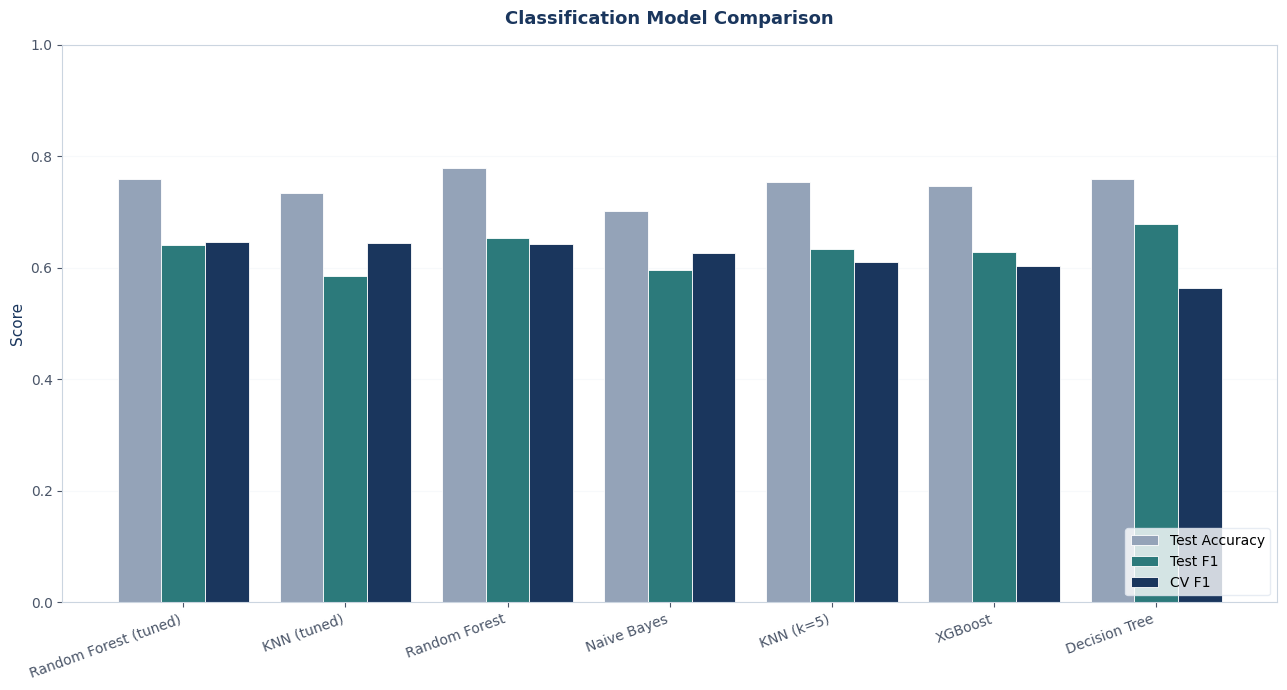


Best model: Random Forest (tuned)
CV F1 = 0.6460
Test Accuracy = 0.7597


In [16]:
comparison = pd.DataFrame({
    'Model': ['KNN (k=5)', 'KNN (tuned)', 'Decision Tree', 'Naive Bayes',
              'Random Forest', 'Random Forest (tuned)', 'XGBoost'],
    'Test Accuracy': [acc_knn,  acc_knn_tuned, acc_dt,          acc_nb,
                      acc_rf,   acc_rf_tuned,  acc_xgb],
    'Test F1-Score': [f1_knn,   f1_knn_tuned,  f1_dt,           f1_nb,
                      f1_rf,    f1_rf_tuned,   f1_xgb],
    'CV F1-Score':   [cv_knn,   cv_knn_tuned,  cv_dt,           cv_nb,
                      cv_rf,    cv_rf_tuned,   cv_xgb]
}).sort_values('CV F1-Score', ascending=False).reset_index(drop=True)

print("Model Comparison (sorted by CV F1):")
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 7))
x = np.arange(len(comparison))
width = 0.27

ax.bar(x - width, comparison['Test Accuracy'], width, label='Test Accuracy',
       color='#94a3b8', edgecolor='white', linewidth=0.6)
ax.bar(x,         comparison['Test F1-Score'], width, label='Test F1',
       color=TEAL, edgecolor='white', linewidth=0.6)
ax.bar(x + width, comparison['CV F1-Score'],   width, label='CV F1',
       color=NAVY, edgecolor='white', linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison', pad=15)
ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor=SOFT)
ax.grid(alpha=0.4, axis='y')
ax.set_ylim(0, 1)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

best_model = comparison.iloc[0]
print(f"\nBest model: {best_model['Model']}")
print(f"CV F1 = {best_model['CV F1-Score']:.4f}")
print(f"Test Accuracy = {best_model['Test Accuracy']:.4f}")

# Part 2: Clustering

Clustering is applied without using the Outcome column, to discover natural groupings. We use X_train_scaled since clustering is sensitive to feature scales.

## 16. K-Means

In [17]:
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_train_scaled)
sil_kmeans = silhouette_score(X_train_scaled, clusters_kmeans)
print(f"K-Means Silhouette Score: {sil_kmeans:.4f}")
print(f"Cluster sizes: {np.bincount(clusters_kmeans)}")

K-Means Silhouette Score: 0.1931
Cluster sizes: [291 323]


## 17. K-Medoids

Similar to K-Means but uses actual data points as cluster centers, which makes it more robust to outliers.

In [18]:
kmedoids = KMedoids(n_clusters=2, random_state=RANDOM_STATE)
clusters_kmedoids = kmedoids.fit_predict(X_train_scaled)
sil_kmedoids = silhouette_score(X_train_scaled, clusters_kmedoids)
print(f"K-Medoids Silhouette Score: {sil_kmedoids:.4f}")
print(f"Cluster sizes: {np.bincount(clusters_kmedoids)}")

K-Medoids Silhouette Score: 0.1776
Cluster sizes: [371 243]


### Visual Comparison: K-Means vs K-Medoids

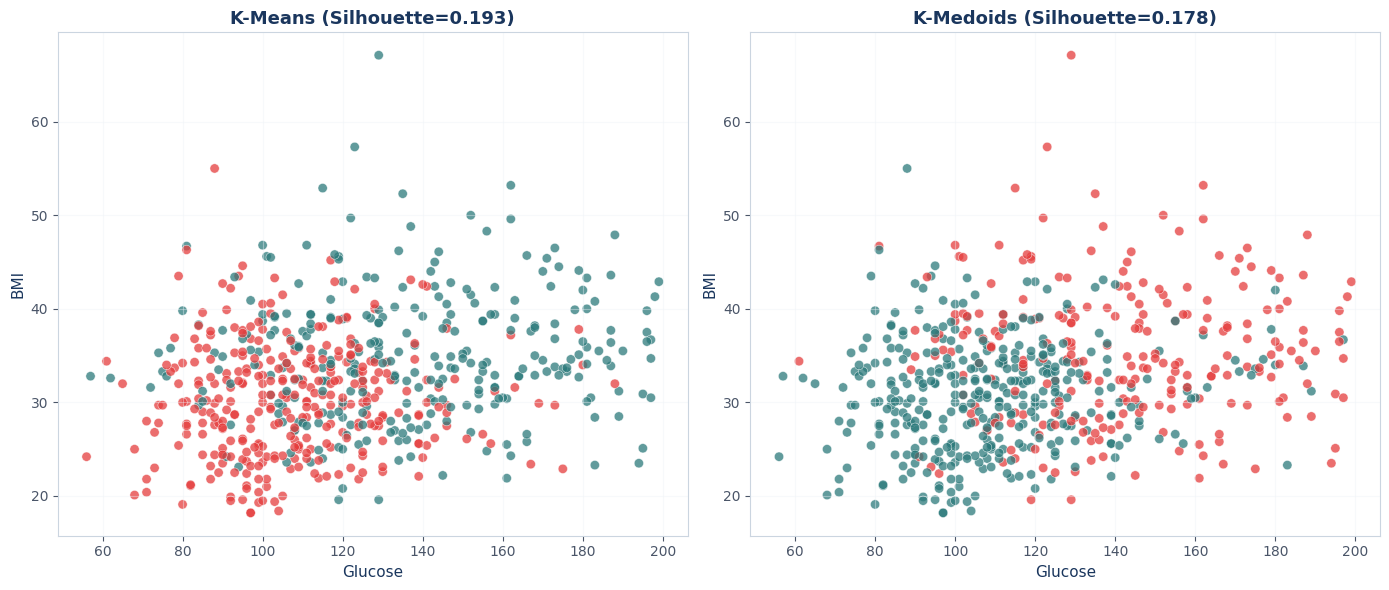

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Use a two-tone teal/navy scheme for clusters
cluster_colors = [TEAL, CORAL]
from matplotlib.colors import ListedColormap
cmap_clusters = ListedColormap(cluster_colors)

ax[0].scatter(X_train['Glucose'], X_train['BMI'],
              c=clusters_kmeans, cmap=cmap_clusters, alpha=0.75, s=45,
              edgecolors='white', linewidth=0.4)
ax[0].set_title(f'K-Means (Silhouette={sil_kmeans:.3f})')
ax[0].set_xlabel('Glucose')
ax[0].set_ylabel('BMI')
ax[0].grid(alpha=0.4)

ax[1].scatter(X_train['Glucose'], X_train['BMI'],
              c=clusters_kmedoids, cmap=cmap_clusters, alpha=0.75, s=45,
              edgecolors='white', linewidth=0.4)
ax[1].set_title(f'K-Medoids (Silhouette={sil_kmedoids:.3f})')
ax[1].set_xlabel('Glucose')
ax[1].set_ylabel('BMI')
ax[1].grid(alpha=0.4)
plt.tight_layout()
plt.show()

## 18. DBSCAN with Automatic Parameter Tuning

DBSCAN is sensitive to the eps parameter. Two-step tuning:

1. Plot k-distances and identify the elbow as a starting point for eps.
2. Run a grid search over (eps, min_samples) and select the combination with the best silhouette.

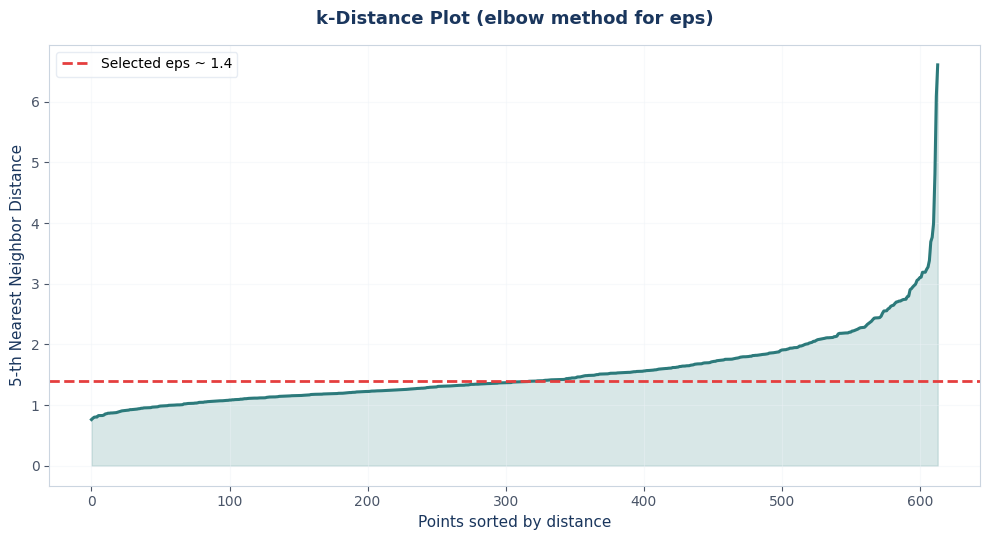

In [20]:
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_train_scaled)
distances, _ = nn.kneighbors(X_train_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5.5))
plt.plot(k_dist, linewidth=2.2, color=TEAL)
plt.fill_between(range(len(k_dist)), k_dist, alpha=0.18, color=TEAL)
plt.axhline(y=1.4, color=CORAL, linestyle='--', linewidth=2, label='Selected eps ~ 1.4')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance')
plt.title('k-Distance Plot (elbow method for eps)', pad=15)
plt.legend(frameon=True, facecolor='white', edgecolor=SOFT)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [21]:
def auto_tune_dbscan(data, eps_range, min_samples_range):
    best = {'silhouette': -1, 'eps': None, 'min_samples': None,
            'n_clusters': 0, 'n_noise': 0, 'labels': None}
    results = []
    for eps in eps_range:
        for ms in min_samples_range:
            db = DBSCAN(eps=eps, min_samples=ms).fit(data)
            n_c = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
            n_n = (db.labels_ == -1).sum()
            if n_c >= 2 and (n_n / len(data)) < 0.6:
                mask = db.labels_ != -1
                if mask.sum() > 10:
                    sil = silhouette_score(data[mask], db.labels_[mask])
                    results.append((eps, ms, n_c, n_n, sil))
                    if sil > best['silhouette']:
                        best = {'silhouette': sil, 'eps': eps, 'min_samples': ms,
                                'n_clusters': n_c, 'n_noise': n_n,
                                'labels': db.labels_}
    return best, results

eps_range = np.arange(0.8, 2.2, 0.1)
min_samples_range = [3, 5, 7, 10]
best_dbscan, all_results = auto_tune_dbscan(X_train_scaled, eps_range, min_samples_range)

print("Best DBSCAN parameters:")
print(f"  eps          = {best_dbscan['eps']:.2f}")
print(f"  min_samples  = {best_dbscan['min_samples']}")
print(f"  n_clusters   = {best_dbscan['n_clusters']}")
print(f"  n_noise      = {best_dbscan['n_noise']}")
print(f"  silhouette   = {best_dbscan['silhouette']:.4f}")

clusters_dbscan = best_dbscan['labels']
sil_dbscan = best_dbscan['silhouette']

Best DBSCAN parameters:
  eps          = 1.40
  min_samples  = 7
  n_clusters   = 2
  n_noise      = 221
  silhouette   = 0.2601


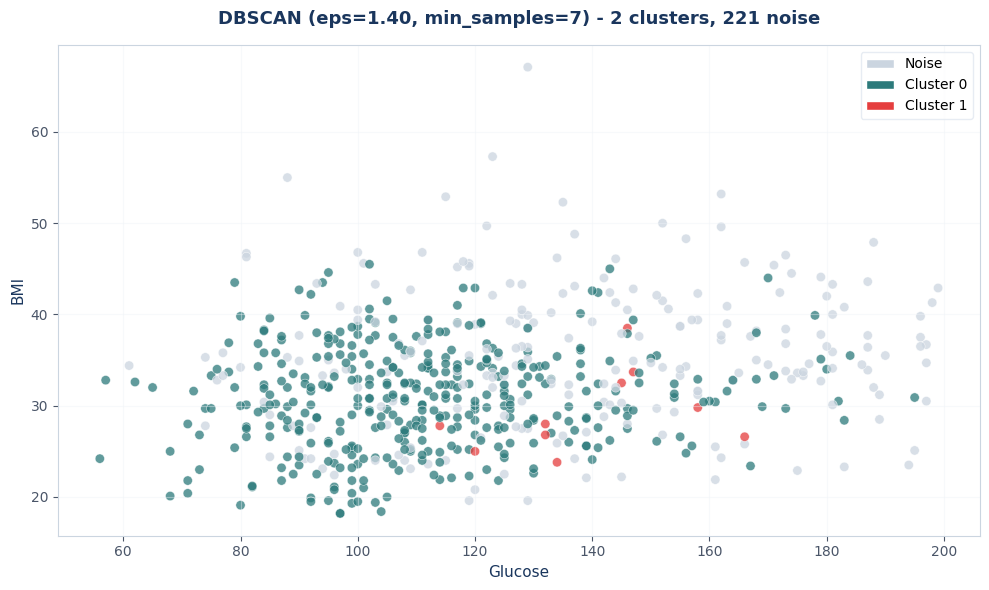

In [22]:
# Build a clean colormap: noise = gray, clusters = teal/coral
unique_labels = sorted(set(clusters_dbscan))
cluster_palette = [TEAL, CORAL, GOLD, MINT, NAVY]
label_to_color = {}
ci = 0
for lbl in unique_labels:
    if lbl == -1:
        label_to_color[lbl] = '#cbd5e0'
    else:
        label_to_color[lbl] = cluster_palette[ci % len(cluster_palette)]
        ci += 1
point_colors = [label_to_color[l] for l in clusters_dbscan]

plt.figure(figsize=(10, 6))
plt.scatter(X_train['Glucose'], X_train['BMI'],
            c=point_colors, alpha=0.75, s=45,
            edgecolors='white', linewidth=0.4)
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title(f'DBSCAN (eps={best_dbscan["eps"]:.2f}, min_samples={best_dbscan["min_samples"]}) - '
          f'{best_dbscan["n_clusters"]} clusters, {best_dbscan["n_noise"]} noise',
          pad=15)
# Manual legend
from matplotlib.patches import Patch
legend_items = []
for lbl, col in label_to_color.items():
    name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    legend_items.append(Patch(facecolor=col, edgecolor='white', label=name))
plt.legend(handles=legend_items, frameon=True, facecolor='white', edgecolor=SOFT)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## 19. STING - Hierarchical Grid Implementation

STING (STatistical INformation Grid) builds a hierarchical grid using a quadtree structure. For each cell we store count, mean, std, min, and max. Dense leaf cells (above a density threshold) are merged into clusters using BFS on adjacency.

In [23]:
class STINGCell:
    def __init__(self, x_min, x_max, y_min, y_max, points):
        self.x_min, self.x_max = x_min, x_max
        self.y_min, self.y_max = y_min, y_max
        self.points = points
        self.count = len(points)
        if self.count > 0:
            self.mean  = points.mean(axis=0)
            self.std   = points.std(axis=0)
            self.min_v = points.min(axis=0)
            self.max_v = points.max(axis=0)
        else:
            self.mean = self.std = self.min_v = self.max_v = None
        self.children = []
        self.cluster_id = -1


def build_sting_tree(points, x_range, y_range, level, max_level):
    x_min, x_max = x_range
    y_min, y_max = y_range
    in_cell = ((points[:, 0] >= x_min) & (points[:, 0] <= x_max) &
               (points[:, 1] >= y_min) & (points[:, 1] <= y_max))
    cell_pts = points[in_cell]
    cell = STINGCell(x_min, x_max, y_min, y_max, cell_pts)
    if level < max_level and cell.count > 0:
        x_mid = (x_min + x_max) / 2
        y_mid = (y_min + y_max) / 2
        for xr, yr in [((x_min, x_mid), (y_min, y_mid)),
                       ((x_mid, x_max), (y_min, y_mid)),
                       ((x_min, x_mid), (y_mid, y_max)),
                       ((x_mid, x_max), (y_mid, y_max))]:
            cell.children.append(build_sting_tree(points, xr, yr, level + 1, max_level))
    return cell


def get_leaf_cells(cell):
    if not cell.children:
        return [cell] if cell.count > 0 else []
    leaves = []
    for ch in cell.children:
        leaves.extend(get_leaf_cells(ch))
    return leaves


def cells_adjacent(c1, c2, tol=1e-6):
    horiz = (abs(c1.x_max - c2.x_min) < tol or abs(c2.x_max - c1.x_min) < tol)
    vert  = (abs(c1.y_max - c2.y_min) < tol or abs(c2.y_max - c1.y_min) < tol)
    overlap_x = not (c1.x_max < c2.x_min - tol or c2.x_max < c1.x_min - tol)
    overlap_y = not (c1.y_max < c2.y_min - tol or c2.y_max < c1.y_min - tol)
    return (horiz and overlap_y) or (vert and overlap_x)


def sting_cluster(points, max_level=4, density_threshold_pct=70):
    x_range = (points[:, 0].min() - 0.01, points[:, 0].max() + 0.01)
    y_range = (points[:, 1].min() - 0.01, points[:, 1].max() + 0.01)
    root = build_sting_tree(points, x_range, y_range, 0, max_level)
    leaves = get_leaf_cells(root)
    if not leaves:
        return np.full(len(points), -1), root, []
    counts = np.array([c.count for c in leaves])
    thresh = np.percentile(counts, density_threshold_pct)
    dense = [c for c in leaves if c.count >= thresh]

    # BFS merge adjacent dense cells
    cid = 0
    for c in dense:
        if c.cluster_id != -1:
            continue
        c.cluster_id = cid
        queue = [c]
        while queue:
            cur = queue.pop(0)
            for other in dense:
                if other.cluster_id == -1 and cells_adjacent(cur, other):
                    other.cluster_id = cid
                    queue.append(other)
        cid += 1

    labels = np.full(len(points), -1)
    for c in dense:
        in_cell = ((points[:, 0] >= c.x_min) & (points[:, 0] <= c.x_max) &
                   (points[:, 1] >= c.y_min) & (points[:, 1] <= c.y_max))
        labels[in_cell] = c.cluster_id
    return labels, root, dense

In [24]:
glucose_idx = list(X_train.columns).index('Glucose')
bmi_idx     = list(X_train.columns).index('BMI')
pts_2d      = X_train_scaled[:, [glucose_idx, bmi_idx]]

clusters_sting, root, dense_cells = sting_cluster(pts_2d, max_level=4,
                                                  density_threshold_pct=70)
n_sting = len(set(clusters_sting)) - (1 if -1 in clusters_sting else 0)
n_unassigned = (clusters_sting == -1).sum()

print(f"STING hierarchical grid, max_level=4 ({4**4} potential leaf cells)")
print(f"Dense cells: {len(dense_cells)}")
print(f"STING clusters: {n_sting}, unassigned (sparse): {n_unassigned}")

if n_sting > 1:
    mask = clusters_sting != -1
    sil_sting = silhouette_score(pts_2d[mask], clusters_sting[mask])
    print(f"STING Silhouette: {sil_sting:.4f}")
else:
    sil_sting = 0.0

STING hierarchical grid, max_level=4 (256 potential leaf cells)
Dense cells: 42
STING clusters: 2, unassigned (sparse): 205
STING Silhouette: 0.4458


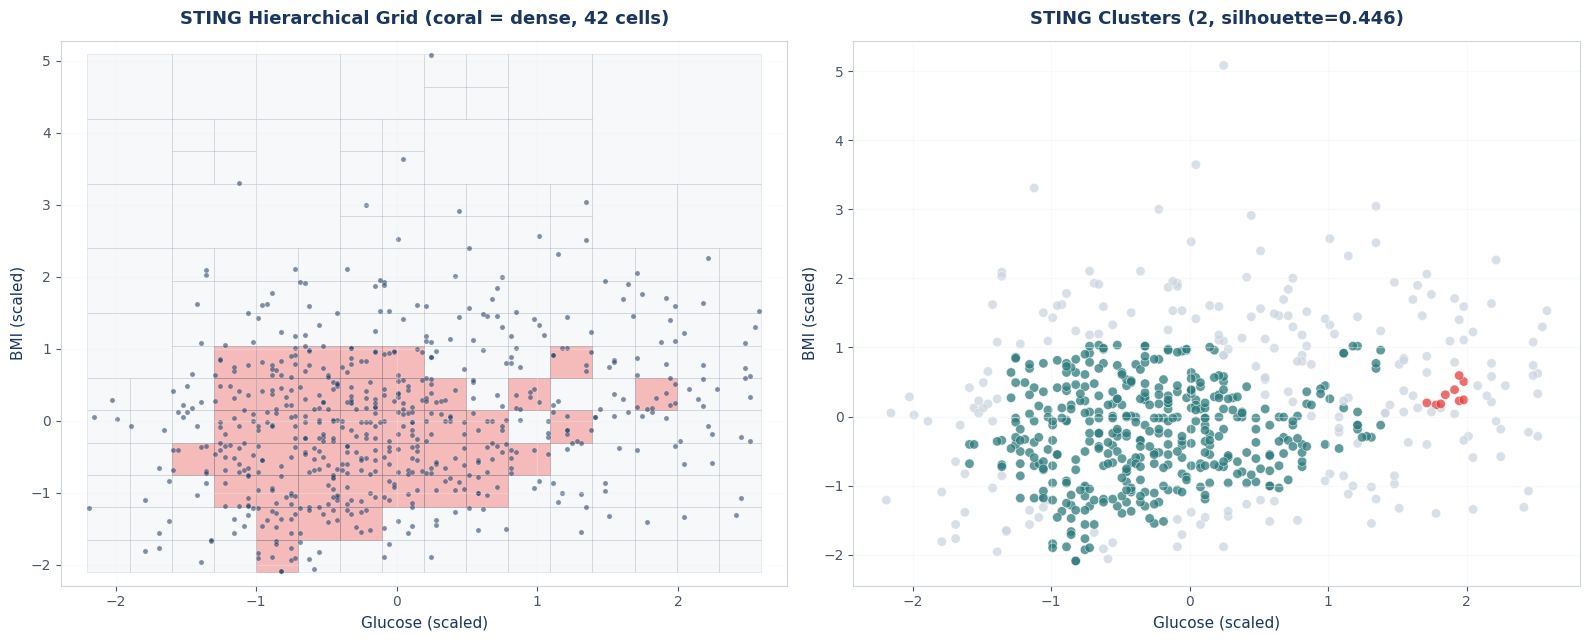

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

ax = axes[0]
def draw_cell(ax, cell):
    from matplotlib.patches import Rectangle
    if not cell.children:
        is_dense = cell in dense_cells
        color = CORAL if is_dense else '#cbd5e0'
        alpha = 0.35 if is_dense else 0.15
        rect = Rectangle((cell.x_min, cell.y_min),
                         cell.x_max - cell.x_min,
                         cell.y_max - cell.y_min,
                         linewidth=0.5, edgecolor=GRAY,
                         facecolor=color, alpha=alpha)
        ax.add_patch(rect)
    else:
        for ch in cell.children:
            draw_cell(ax, ch)

draw_cell(ax, root)
ax.scatter(pts_2d[:, 0], pts_2d[:, 1], s=14, c=NAVY, alpha=0.55,
           edgecolors='white', linewidth=0.3)
ax.set_xlabel('Glucose (scaled)')
ax.set_ylabel('BMI (scaled)')
ax.set_title(f'STING Hierarchical Grid (coral = dense, {len(dense_cells)} cells)', pad=12)
ax.set_xlim(pts_2d[:, 0].min() - 0.2, pts_2d[:, 0].max() + 0.2)
ax.set_ylim(pts_2d[:, 1].min() - 0.2, pts_2d[:, 1].max() + 0.2)
ax.grid(alpha=0.3)

ax = axes[1]
unique_labels = sorted(set(clusters_sting))
cluster_palette = [TEAL, CORAL, GOLD, MINT, NAVY, '#805ad5']
label_to_color = {}
ci = 0
for lbl in unique_labels:
    if lbl == -1:
        label_to_color[lbl] = '#cbd5e0'
    else:
        label_to_color[lbl] = cluster_palette[ci % len(cluster_palette)]
        ci += 1
point_colors = [label_to_color[l] for l in clusters_sting]

ax.scatter(pts_2d[:, 0], pts_2d[:, 1],
           c=point_colors, alpha=0.75, s=45,
           edgecolors='white', linewidth=0.4)
ax.set_xlabel('Glucose (scaled)')
ax.set_ylabel('BMI (scaled)')
ax.set_title(f'STING Clusters ({n_sting}, silhouette={sil_sting:.3f})', pad=12)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## 20. CLIQUE - Subspace Clustering

CLIQUE (CLustering In QUEst) is a density- and grid-based algorithm that finds clusters in subspaces of the data. Each dimension is split into equal-width bins; a unit is dense if its count is at least tau * n. Dense 2D units are built from pairs of dense 1D units (Apriori candidate generation), then merged into clusters. The algorithm reports the 2D subspace with the most dense units.

In [26]:
def clique_cluster(data, n_bins=6, tau=0.03):
    n, d = data.shape
    min_count = int(tau * n)

    data_binned = np.zeros_like(data, dtype=int)
    for j in range(d):
        edges = np.linspace(data[:, j].min(), data[:, j].max() + 1e-9, n_bins + 1)
        data_binned[:, j] = np.clip(np.digitize(data[:, j], edges) - 1, 0, n_bins - 1)

    dense_1d = {}
    for j in range(d):
        counts = np.bincount(data_binned[:, j], minlength=n_bins)
        dense_1d[j] = set(np.where(counts >= min_count)[0])

    dense_2d = {}
    for i1 in range(d):
        for i2 in range(i1 + 1, d):
            if not dense_1d[i1] or not dense_1d[i2]:
                continue
            units = set()
            for b1 in dense_1d[i1]:
                for b2 in dense_1d[i2]:
                    mask = (data_binned[:, i1] == b1) & (data_binned[:, i2] == b2)
                    if mask.sum() >= min_count:
                        units.add((b1, b2))
            if units:
                dense_2d[(i1, i2)] = units

    def merge_2d(units):
        units_list = list(units)
        cluster_of = {u: -1 for u in units_list}
        cid = 0
        for u in units_list:
            if cluster_of[u] != -1:
                continue
            cluster_of[u] = cid
            queue = [u]
            while queue:
                cur = queue.pop(0)
                for other in units_list:
                    if cluster_of[other] != -1:
                        continue
                    if abs(cur[0] - other[0]) + abs(cur[1] - other[1]) == 1:
                        cluster_of[other] = cid
                        queue.append(other)
            cid += 1
        return cluster_of, cid

    if not dense_2d:
        return np.full(n, -1), dense_1d, dense_2d, None

    best_subspace = max(dense_2d.keys(), key=lambda k: len(dense_2d[k]))
    cluster_of, _ = merge_2d(dense_2d[best_subspace])

    labels = np.full(n, -1)
    j1, j2 = best_subspace
    for u, c in cluster_of.items():
        b1, b2 = u
        mask = (data_binned[:, j1] == b1) & (data_binned[:, j2] == b2)
        labels[mask] = c
    return labels, dense_1d, dense_2d, best_subspace

In [27]:
clusters_clique, d1_units, d2_units, best_subspace = clique_cluster(
    X_train_scaled, n_bins=6, tau=0.03)

n_clique = len(set(clusters_clique)) - (1 if -1 in clusters_clique else 0)
n_unassigned_c = (clusters_clique == -1).sum()
feature_names = list(X_train.columns)

if best_subspace is not None:
    best_features = (feature_names[best_subspace[0]], feature_names[best_subspace[1]])
else:
    best_features = (None, None)

print(f"CLIQUE analyzed all {X_train.shape[1]} dimensions")
print("Dense 1D units per feature:")
for j, units in d1_units.items():
    print(f"  {feature_names[j]:25s}: {len(units)} dense bins")
print(f"\n2D subspaces with dense units: {len(d2_units)} / {8*7//2}")
if best_subspace is not None:
    print(f"\nBest subspace: {best_features[0]} x {best_features[1]} "
          f"({len(d2_units[best_subspace])} dense 2D units)")
print(f"CLIQUE clusters: {n_clique}, unassigned: {n_unassigned_c}")

if n_clique > 1:
    mask = clusters_clique != -1
    sil_clique = silhouette_score(X_train_scaled[mask], clusters_clique[mask])
    print(f"CLIQUE Silhouette: {sil_clique:.4f}")
else:
    sil_clique = 0.0

CLIQUE analyzed all 8 dimensions
Dense 1D units per feature:
  Pregnancies              : 4 dense bins
  Glucose                  : 6 dense bins
  BloodPressure            : 4 dense bins
  SkinThickness            : 3 dense bins
  Insulin                  : 3 dense bins
  BMI                      : 4 dense bins
  DiabetesPedigreeFunction : 3 dense bins
  Age                      : 5 dense bins

2D subspaces with dense units: 28 / 28

Best subspace: Pregnancies x Glucose (12 dense 2D units)
CLIQUE clusters: 2, unassigned: 125
CLIQUE Silhouette: 0.2409


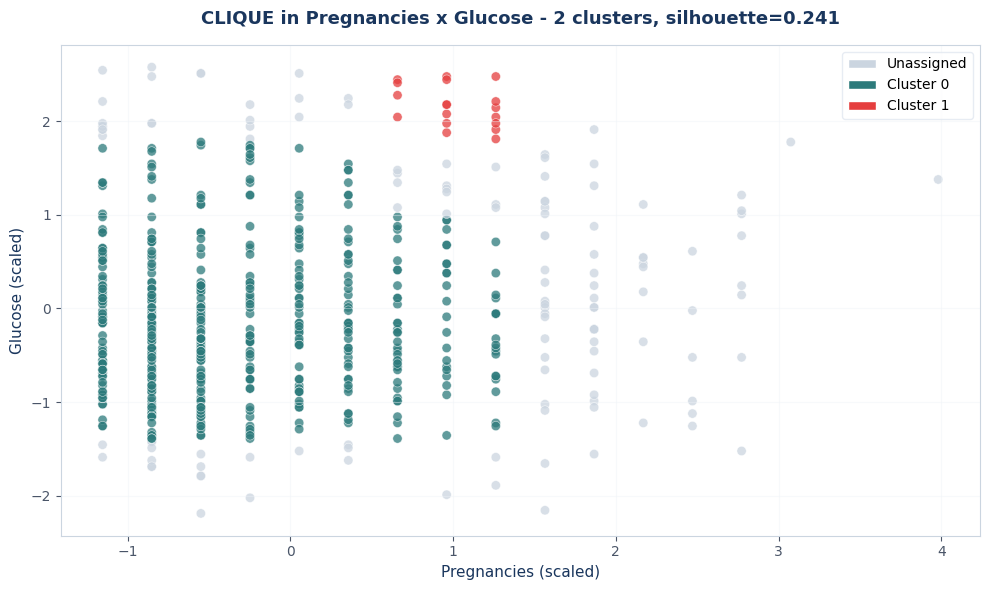

In [28]:
if best_subspace is not None:
    j1, j2 = best_subspace

    unique_labels = sorted(set(clusters_clique))
    cluster_palette = [TEAL, CORAL, GOLD, MINT, NAVY, '#805ad5']
    label_to_color = {}
    ci = 0
    for lbl in unique_labels:
        if lbl == -1:
            label_to_color[lbl] = '#cbd5e0'
        else:
            label_to_color[lbl] = cluster_palette[ci % len(cluster_palette)]
            ci += 1
    point_colors = [label_to_color[l] for l in clusters_clique]

    plt.figure(figsize=(10, 6))
    plt.scatter(X_train_scaled[:, j1], X_train_scaled[:, j2],
                c=point_colors, alpha=0.75, s=45,
                edgecolors='white', linewidth=0.4)
    plt.xlabel(f'{best_features[0]} (scaled)')
    plt.ylabel(f'{best_features[1]} (scaled)')
    plt.title(f'CLIQUE in {best_features[0]} x {best_features[1]} - '
              f'{n_clique} clusters, silhouette={sil_clique:.3f}', pad=15)
    from matplotlib.patches import Patch
    legend_items = []
    for lbl, col in label_to_color.items():
        name = 'Unassigned' if lbl == -1 else f'Cluster {lbl}'
        legend_items.append(Patch(facecolor=col, edgecolor='white', label=name))
    plt.legend(handles=legend_items, frameon=True, facecolor='white', edgecolor=SOFT)
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

## 21. Clustering Final Comparison

In [29]:
clustering_comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'K-Medoids',
                  f'DBSCAN (eps={best_dbscan["eps"]:.2f})',
                  'STING', 'CLIQUE'],
    'Silhouette Score': [sil_kmeans, sil_kmedoids, sil_dbscan, sil_sting, sil_clique],
    'Notes': ['Partition-based', 'Robust to outliers',
              f'{best_dbscan["n_clusters"]} clusters, {best_dbscan["n_noise"]} noise',
              f'Hierarchical grid ({len(dense_cells)} dense cells)',
              f'Best subspace: {best_features[0]} x {best_features[1]}' if best_subspace is not None else 'No dense subspace']
}).sort_values('Silhouette Score', ascending=False).reset_index(drop=True)

print("Clustering Comparison (sorted by Silhouette):")
print(clustering_comparison.to_string(index=False))

Clustering Comparison (sorted by Silhouette):
        Algorithm  Silhouette Score                                Notes
            STING          0.445750   Hierarchical grid (42 dense cells)
DBSCAN (eps=1.40)          0.260067                2 clusters, 221 noise
           CLIQUE          0.240936 Best subspace: Pregnancies x Glucose
          K-Means          0.193145                      Partition-based
        K-Medoids          0.177632                   Robust to outliers


# Part 3: Association Rule Mining

## 22. Apriori

Continuous features are discretized into bins before mining. min_support = 0.1, min_confidence = 0.6.

In [30]:
df_rules = df_clean.copy()
df_rules['Glucose_Bin'] = pd.cut(df_rules['Glucose'],
                                  bins=[0, 100, 140, np.inf],
                                  labels=['Glucose_Low', 'Glucose_Medium', 'Glucose_High'])
df_rules['BMI_Bin']     = pd.cut(df_rules['BMI'],
                                  bins=[0, 25, 30, np.inf],
                                  labels=['BMI_Normal', 'BMI_Overweight', 'BMI_Obese'])
df_rules['Age_Bin']     = pd.cut(df_rules['Age'],
                                  bins=[0, 30, 60, np.inf],
                                  labels=['Age_Young', 'Age_Middle', 'Age_Old'])
df_rules['Outcome_Bin'] = df_rules['Outcome'].map({0: 'No_Diabetes', 1: 'Diabetes'})

transactions = df_rules[['Glucose_Bin', 'BMI_Bin', 'Age_Bin', 'Outcome_Bin']].astype(str).values.tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_trans, min_support=0.1, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)
print(f"Frequent itemsets: {len(frequent_itemsets)}")
print(frequent_itemsets.head(10).to_string(index=False))

Frequent itemsets: 49
 support                                 itemsets
0.651042                 frozenset({No_Diabetes})
0.619792                   frozenset({BMI_Obese})
0.542969                   frozenset({Age_Young})
0.477865              frozenset({Glucose_Medium})
0.425781      frozenset({No_Diabetes, Age_Young})
0.421875                  frozenset({Age_Middle})
0.348958                    frozenset({Diabetes})
0.337240      frozenset({No_Diabetes, BMI_Obese})
0.324219 frozenset({No_Diabetes, Glucose_Medium})
0.317708        frozenset({Age_Young, BMI_Obese})


In [31]:
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.6)
rules = rules.sort_values('lift', ascending=False)
print(f"Rules with confidence >= 0.6: {len(rules)}")
print("\nTop 10 rules by lift:")
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(rules[display_cols].head(10).to_string(index=False))

diabetes_rules = rules[rules['consequents'].astype(str).str.contains('Diabetes')]
print(f"\nRules predicting Diabetes outcome: {len(diabetes_rules)}")
if len(diabetes_rules) > 0:
    print(diabetes_rules[display_cols].head(10).to_string(index=False))

Rules with confidence >= 0.6: 35

Top 10 rules by lift:
                          antecedents                         consequents  support  confidence     lift
frozenset({Age_Middle, Glucose_High})               frozenset({Diabetes}) 0.110677    0.772727 2.214383
 frozenset({BMI_Obese, Glucose_High})               frozenset({Diabetes}) 0.145833    0.756757 2.168616
            frozenset({Glucose_High})               frozenset({Diabetes}) 0.171875    0.687500 1.970149
   frozenset({Age_Middle, BMI_Obese})               frozenset({Diabetes}) 0.174479    0.609091 1.745455
             frozenset({Glucose_Low}) frozenset({No_Diabetes, Age_Young}) 0.177083    0.650718 1.528291
  frozenset({Diabetes, Glucose_High})             frozenset({Age_Middle}) 0.110677    0.643939 1.526375
                frozenset({Diabetes})             frozenset({Age_Middle}) 0.222656    0.638060 1.512438
     frozenset({Diabetes, BMI_Obese})             frozenset({Age_Middle}) 0.174479    0.617512 1.463731
  frozen

# Summary

Key points:

1. Cleaning the data (replacing misleading zeros with medians) improved every classifier.
2. F1 and cross-validation are more informative than accuracy alone on this imbalanced dataset.
3. Limiting Decision Tree depth to 5 reduces overfitting while keeping the model readable.
4. Auto-tuned DBSCAN found meaningful clusters where the default parameters failed.
5. The STING hierarchical grid produced the strongest 2D clustering structure.
6. CLIQUE's subspace search identified the most informative feature pair automatically.
7. Apriori produced interpretable rules linking high glucose, obesity, and middle age to diabetes.
